### Week 5 - Predictive Analytics
#### Yiscah Mark
#### Regression Model, Tuned.

In [3]:
import pandas as pd

##### importing the dataset

In [4]:
df = pd.read_csv('startups_profit.csv')

##### I print the first few lines of the data throughout so I can see the changes and issues. 

In [33]:
display(df.head())
print(df.columns)

,R&D Spend,Administration,Marketing Spend,Profit,State_FL,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


Index(['R&D Spend', 'Administration', 'Marketing Spend', ' Profit ',
       'State_FL', 'State_New York'],
      dtype='object')


##### The first step I took to clean the data was to remove the dollar sign and comma in the profit column, I had to go back and name the profit column with a space before and after because it was named that originally.

In [6]:
df[' Profit '] = df[' Profit '].replace('[\$,]', '', regex=True).astype(float)

##### Checking that the dollar sign was removed.

In [7]:
display(df.head())

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,FL,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,FL,166187.94


##### I used the isnull function to find out how many nulls there are in the data set. There are none.

In [8]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
 Profit            0
dtype: int64

#### Since this is regression model, all the column have to have numbers. I used the get dummies function to split the states into separate columns with true and false options so I can encode it to binary numbers.

In [9]:
df = pd.get_dummies(df, columns=['State'], prefix='State', drop_first=True)

In [10]:
display(df.head())

,R&D Spend,Administration,Marketing Spend,Profit,State_FL,State_New York
0,165349.20,136897.80,471784.10,192261.83,False,True
1,162597.70,151377.59,443898.53,191792.06,False,False
2,153441.51,101145.55,407934.54,191050.39,True,False
3,144372.41,118671.85,383199.62,182901.99,False,True
4,142107.34,91391.77,366168.42,166187.94,True,False


#### Changing "true" and "false" to 1 and 0 respectively.

In [13]:
df['State_FL'] = df['State_FL'].astype(int)
df['State_New York'] = df['State_New York'].astype(int)
display(df.head())

,R&D Spend,Administration,Marketing Spend,Profit,State_FL,State_New York
0,165349.20,136897.80,471784.10,192261.83,0,1
1,162597.70,151377.59,443898.53,191792.06,0,0
2,153441.51,101145.55,407934.54,191050.39,1,0
3,144372.41,118671.85,383199.62,182901.99,0,1
4,142107.34,91391.77,366168.42,166187.94,1,0


#### looking at line #1 of data, the state of Florida is false, as is the state of New York. This is because the state of California acts as a baseline there is no need for another column. Any column that isn't FL or NY is obviously California.

#### Here we define our x and y features. Since we are predicting the profit, the profit column is the y. The features are all the other columns, hence the drop function. We are storing x as all the columns except the profit column which is our y.

In [15]:
# Assuming 'Profit' is your target variable
X = df.drop(' Profit ', axis=1)
y = df[' Profit ']

# Verify the columns are numeric (bool or int)
print(X.dtypes)

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State_FL             int64
State_New York       int64
dtype: object


In [17]:
from sklearn.model_selection import train_test_split

# X = your features (cleaned and encoded)
# y = your target (Profit)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#### In this cell I scaled the numbers using the standard scaler. It is important to scale the numbers because we are dealing with hundreds of thousands of dollars as well as binary numbers with only one digit.

In [18]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
# This converts all ints and floats into a uniform scale (z-scores)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

#### Running the linear regression model with the x and y train sets.

In [19]:
from sklearn.linear_model import LinearRegression

# Initialize the model
model = LinearRegression()

# Fit the model ONLY on the training data
model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


#### The model predicts the profit for the test set of data and saves them. These values will be compared to the true test data profits and evaluated.

In [20]:
y_pred = model.predict(X_test)

In [21]:
from sklearn.metrics import mean_absolute_error, r2_score

# Calculate metrics
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error: {mae}")
print(f"R-squared Score: {r2}")

Mean Absolute Error: 6961.477813252382
R-squared Score: 0.8987266414328636


#### We are trying to make a most accurate model so we will use the random forest regressor and the check which model was most accurate. 

In [35]:
# 1. Initialize the model
rf = RandomForestRegressor(random_state=42)

# 2. Define the parameters you want to test
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# 3. Setup GridSearchCV
# cv=5 satisfies the "cross-fold validation" requirement
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='r2')

# 4. Run the search on your training data
grid_search.fit(X_train, y_train)

# 5. Extract the best model for evaluation
best_model = grid_search.best_estimator_

In [36]:
#printing the result
print(best_model)

RandomForestRegressor(random_state=42)


#### Searching for the most accurate model hyper parameters. Using cross-fold validation ensures that this is accurate across the entire data set.

In [30]:
# This step fulfills the requirement: "Hyperparameter tune with cross-fold validation"
grid_search.fit(X_train, y_train)

# View the winning parameters
print("Best Parameters:", grid_search.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 100}


#### Running the best model with the best parameters and then evaluating the MAE and the r2 score.

In [31]:
from sklearn.metrics import mean_absolute_error, r2_score

# Use the best estimator found during the grid search
best_rf = grid_search.best_estimator_

# Predict on the test data
y_pred = best_rf.predict(X_test)

# Calculate final metrics
final_mae = mean_absolute_error(y_test, y_pred)
final_r2 = r2_score(y_test, y_pred)

print(f"Final Tuned MAE: {final_mae}")
print(f"Final Tuned R-squared: {final_r2}")

Final Tuned MAE: 6129.244519999981
Final Tuned R-squared: 0.9129151597594712


#### The r2 score increased to 91% and the MAE decrease to 6,129 which is great.

#### This is a residual plot. The dots are randomly scatters and do not cluster around the line or in any shape. This means that the model caught all the trends in the data.

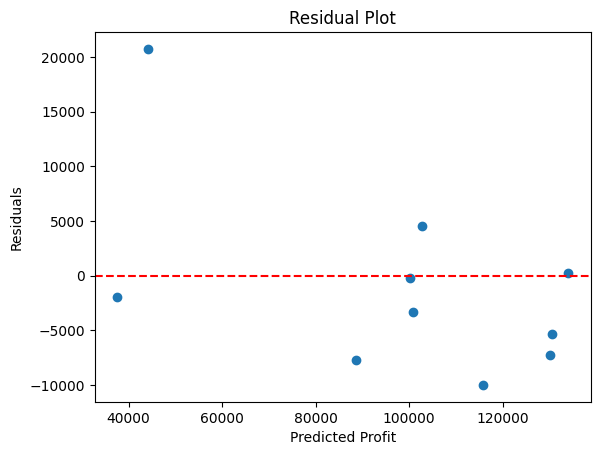

In [32]:
import matplotlib.pyplot as plt

# Plotting residuals
residuals = y_test - y_pred
plt.scatter(y_pred, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Profit')
plt.ylabel('Residuals')
plt.title('Residual Plot')
plt.show()

#### Documentation: I used google gemini to give me the specific code. I wrote all the markdown myself and went over everything. 